In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
 
warnings.filterwarnings("ignore")
 

# Load dataset

In [5]:
df_full = pd.read_csv("/Users/savv/breast_cancer_40_features_1M.csv")

df_full.shape
df_full

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,nucleus_size,nucleus_texture,mitosis_rate,tumor_border_irregularity,chromatin_density,cell_variation,nuclear_variation,cytoplasm_ratio,cell_clump_thickness,diagnosis
0,16.021426,15.900191,80.338711,806.403104,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,...,9.387159,-0.013497,2.903146,0.574452,-1.220844,0.208864,-1.959670,-1.328186,0.196861,1
1,14.074327,14.990334,72.827789,622.307690,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,...,9.823466,-0.035826,4.392747,0.189660,0.821903,0.087047,-0.299007,0.091761,-1.987569,0
2,14.893529,17.008014,89.946616,696.859332,-0.808494,-0.501757,0.915402,0.328751,-0.529760,0.513267,...,6.934019,0.060230,1.160965,0.681766,0.301547,-0.034712,-1.168678,1.142823,0.751933,0
3,9.392390,16.336167,54.760612,277.141849,0.586857,2.190456,-0.990536,-0.566298,0.099651,-0.503476,...,11.714646,-0.680025,6.051220,0.400866,-0.714351,1.865775,0.473833,-1.191303,0.656554,0
4,18.038859,18.218585,129.752145,1022.275649,0.963376,0.412781,0.822060,1.896793,-0.245388,-0.753736,...,10.946676,0.214094,3.707148,0.506364,0.385317,-0.883857,0.153725,0.058209,-1.142970,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,10.563092,20.707178,60.115935,350.535472,-0.680941,0.806848,-3.053026,1.119201,0.478958,-1.105285,...,9.159216,-0.507837,3.389152,0.330467,0.288776,-1.525836,-0.197846,-0.667790,-1.036613,0
499996,14.749672,17.870529,82.049955,683.462326,-1.146484,1.166144,-0.676306,-0.178681,1.254180,-0.161609,...,11.809745,-1.521662,4.265612,0.750254,0.469740,1.923337,1.734447,-0.432242,-0.491788,1
499997,17.794185,17.219667,103.816799,994.731921,0.123155,0.283107,1.100847,1.739299,-0.570598,0.576330,...,3.528912,-0.594282,1.382729,0.544913,0.334020,0.739370,0.152360,-0.714576,0.469693,1
499998,18.926931,15.608882,110.350139,1125.408721,0.269579,-3.067531,1.594309,-0.934860,-0.256229,0.946486,...,14.772733,-0.569116,6.908285,0.639638,1.572027,-1.032348,-2.052788,0.135228,0.250892,1


In [6]:
df = df_full

# EDA

In [7]:
# info
print(df.dtypes.value_counts())

float64    40
int64       1
Name: count, dtype: int64


In [8]:
# statistik deskriptif
target_col = 'diagnosis'
feature_cols = [c for c in df.columns if c != target_col]
summary = df[feature_cols].agg(['mean','std','min','max']).T
summary['skewness'] = df[feature_cols].skew()
summary = summary.round(3)
print(summary.to_string())

                              mean      std    min       max  skewness
radius_mean                 13.998    3.003  0.168    28.689     0.004
texture_mean                19.998    5.001  0.024    43.231    -0.004
perimeter_mean              83.975   19.362  0.909   179.970     0.156
area_mean                  643.922  267.268  0.088  2585.669     0.634
smoothness_mean             -0.000    0.998 -4.872     4.814    -0.001
compactness_mean             0.000    1.001 -4.574     5.220     0.001
concavity_mean               0.000    0.999 -4.573     5.022    -0.003
concave_points_mean          0.001    1.000 -4.677     4.655    -0.005
symmetry_mean                0.001    1.000 -4.482     4.611    -0.000
fractal_dimension_mean       0.001    1.000 -4.625     4.575    -0.000
radius_se                   -0.000    1.001 -4.980     4.719     0.001
texture_se                   0.003    1.001 -4.717     4.798     0.007
perimeter_se                -0.002    1.000 -4.829     5.076     0.000
area_s

In [9]:
# cek missing value
missing = df.isnull().sum()
print(missing)

radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave_points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave_points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave_points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
cell_density                 0
nucleus_size                 0
nucleus_

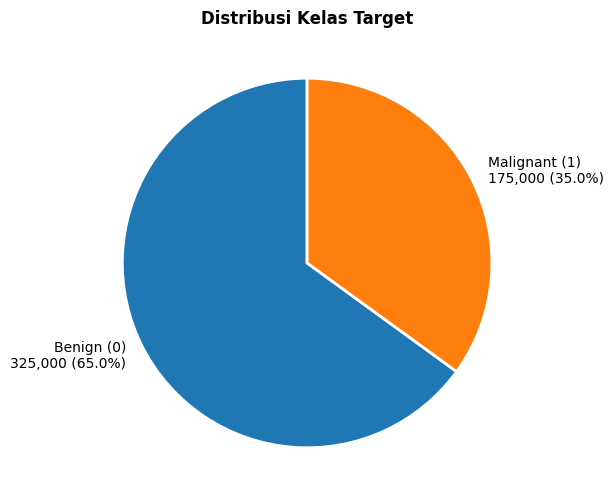

In [10]:
# distribusi kelas target
target_col = 'diagnosis'
counts = df[target_col].value_counts()
labels = ['Benign (0)', 'Malignant (1)']

plt.figure(figsize=(6, 6))
plt.pie(
    counts.values,
    labels=[f'{l}\n{v:,} ({v/len(df)*100:.1f}%)' for l, v in zip(labels, counts.values)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Distribusi Kelas Target', fontweight='bold')
plt.show()

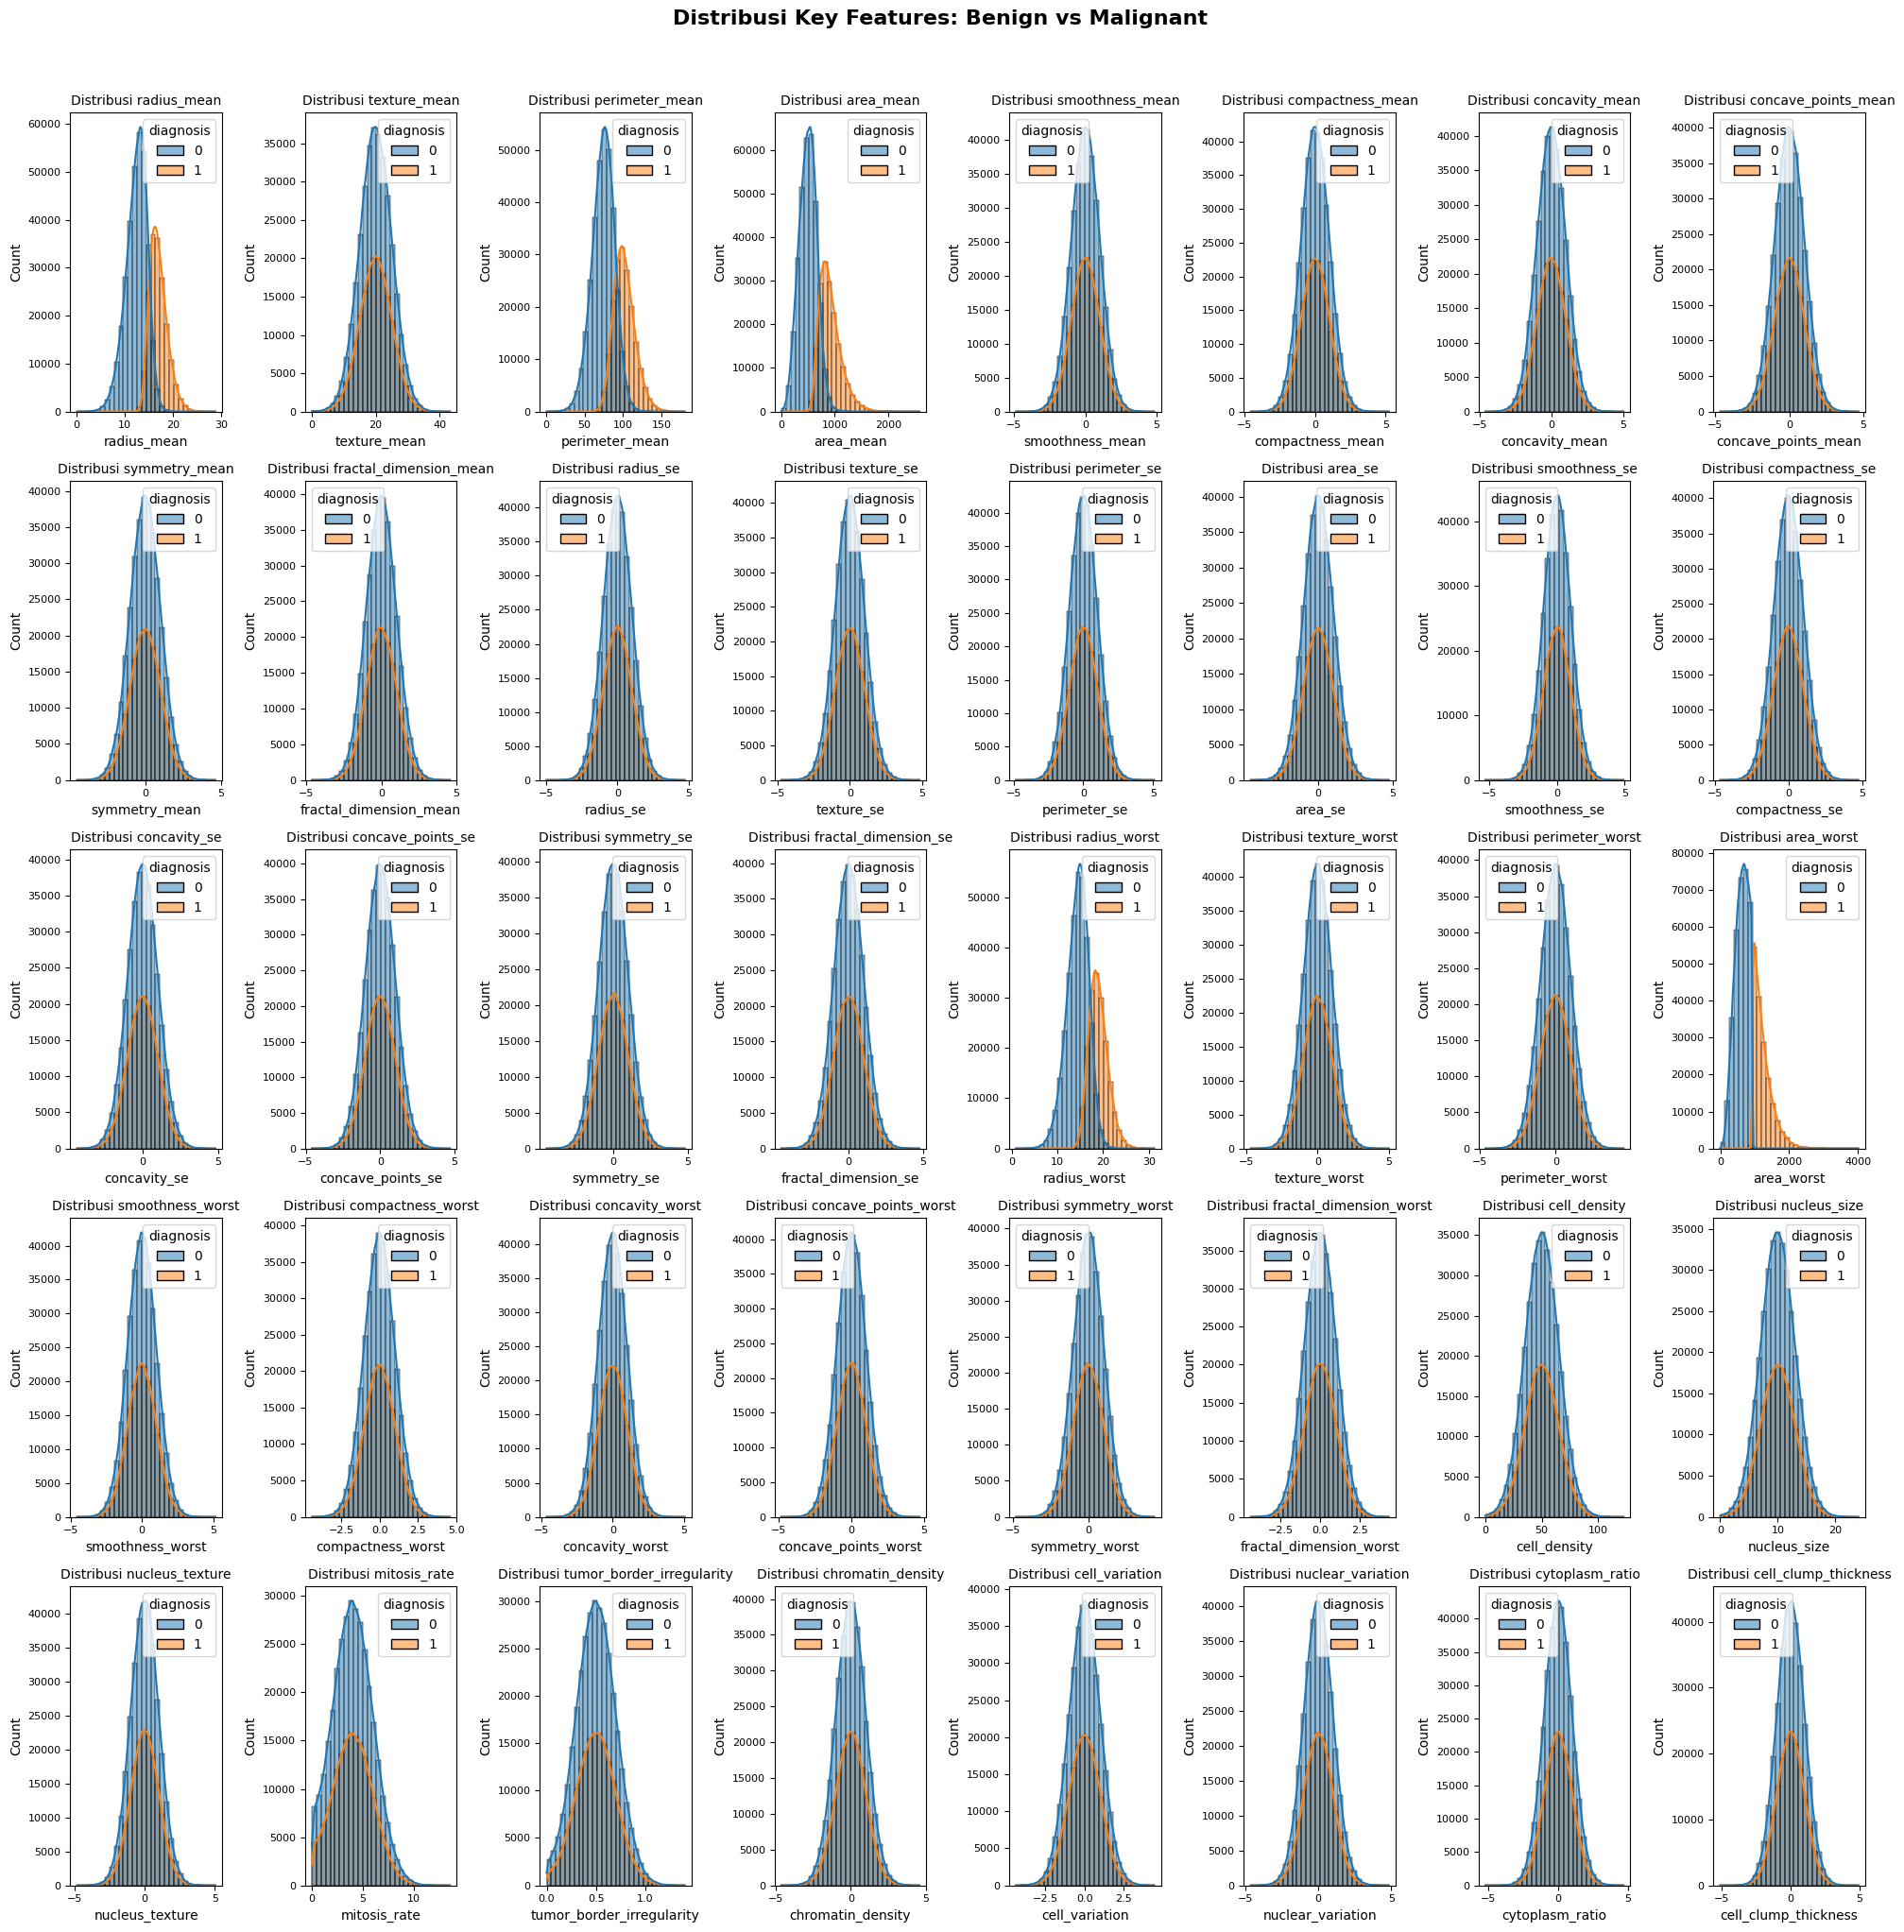

In [11]:

n_cols = 8
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_cols):

    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        bins=30,
        kde=True,
        alpha=0.5,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribusi {col}', fontsize=10)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Distribusi Key Features: Benign vs Malignant',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

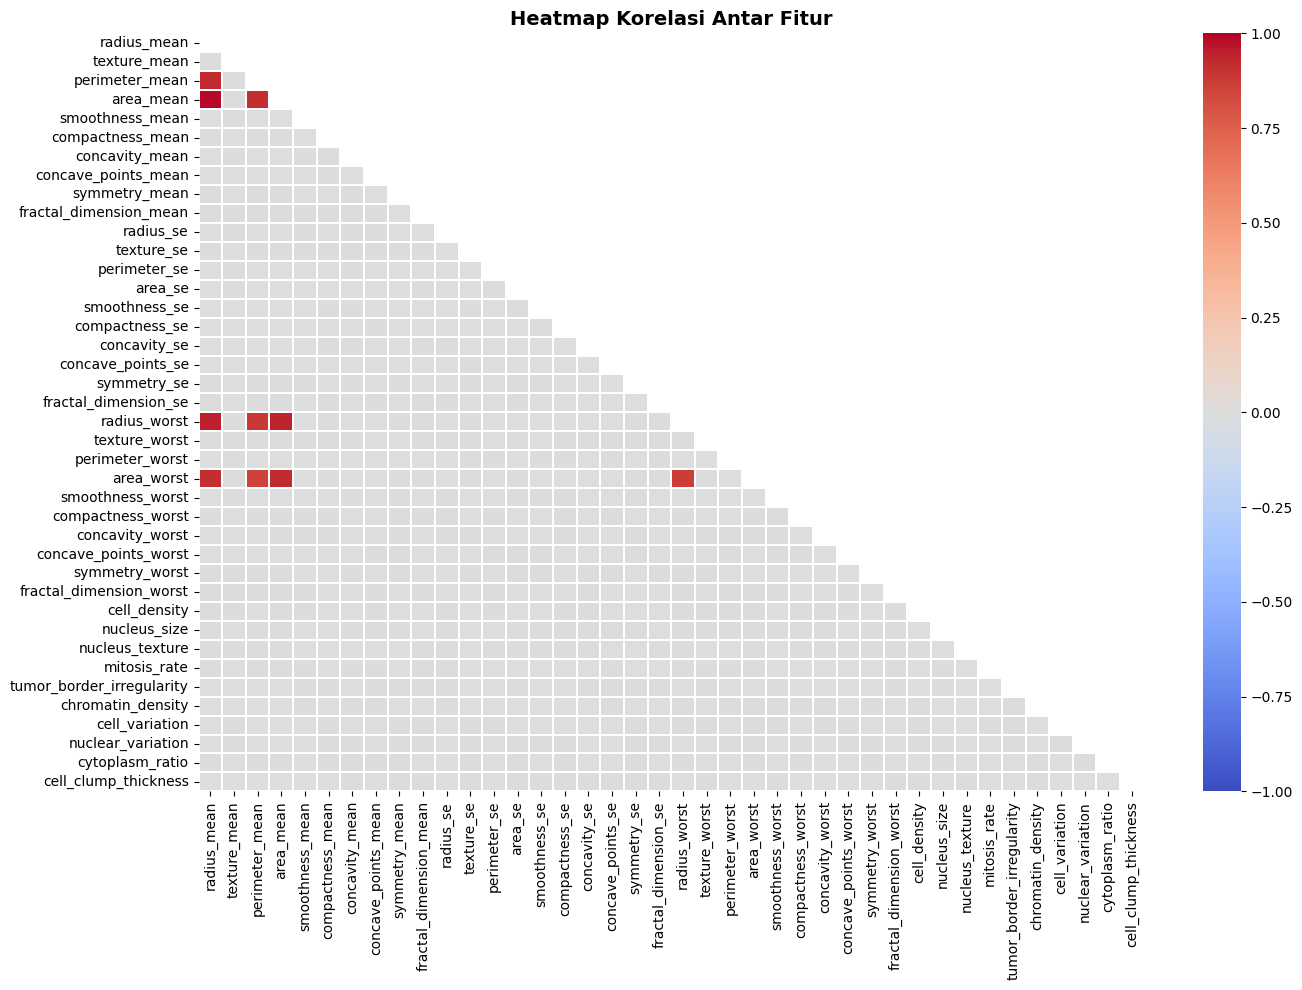

In [12]:
# Heatmap korelasi
corr_matrix = df[feature_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=False,
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# pasangan fitur dengan korelasi sangat tinggi (> 0.95)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                               round(corr_matrix.iloc[i, j], 3)))

pd.DataFrame(high_corr, columns=['Fitur A', 'Fitur B', 'Korelasi'])

,Fitur A,Fitur B,Korelasi
0,radius_mean,area_mean,0.989
1,radius_mean,radius_worst,0.952


In [14]:
# cek outlier
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR))
outlier_counts = outlier_mask.sum().sort_values(ascending=False)
print(outlier_counts)

area_worst                   8894
area_mean                    6612
perimeter_mean               3990
concavity_se                 3599
smoothness_mean              3592
cell_variation               3588
concave_points_worst         3566
texture_worst                3553
texture_mean                 3547
nucleus_size                 3543
nuclear_variation            3538
perimeter_worst              3529
chromatin_density            3527
concavity_worst              3513
smoothness_se                3513
fractal_dimension_worst      3512
perimeter_se                 3507
symmetry_se                  3507
fractal_dimension_se         3500
cell_clump_thickness         3498
compactness_se               3477
cytoplasm_ratio              3476
area_se                      3475
compactness_worst            3472
concave_points_mean          3470
texture_se                   3469
concave_points_se            3461
symmetry_worst               3456
cell_density                 3456
fractal_dimens

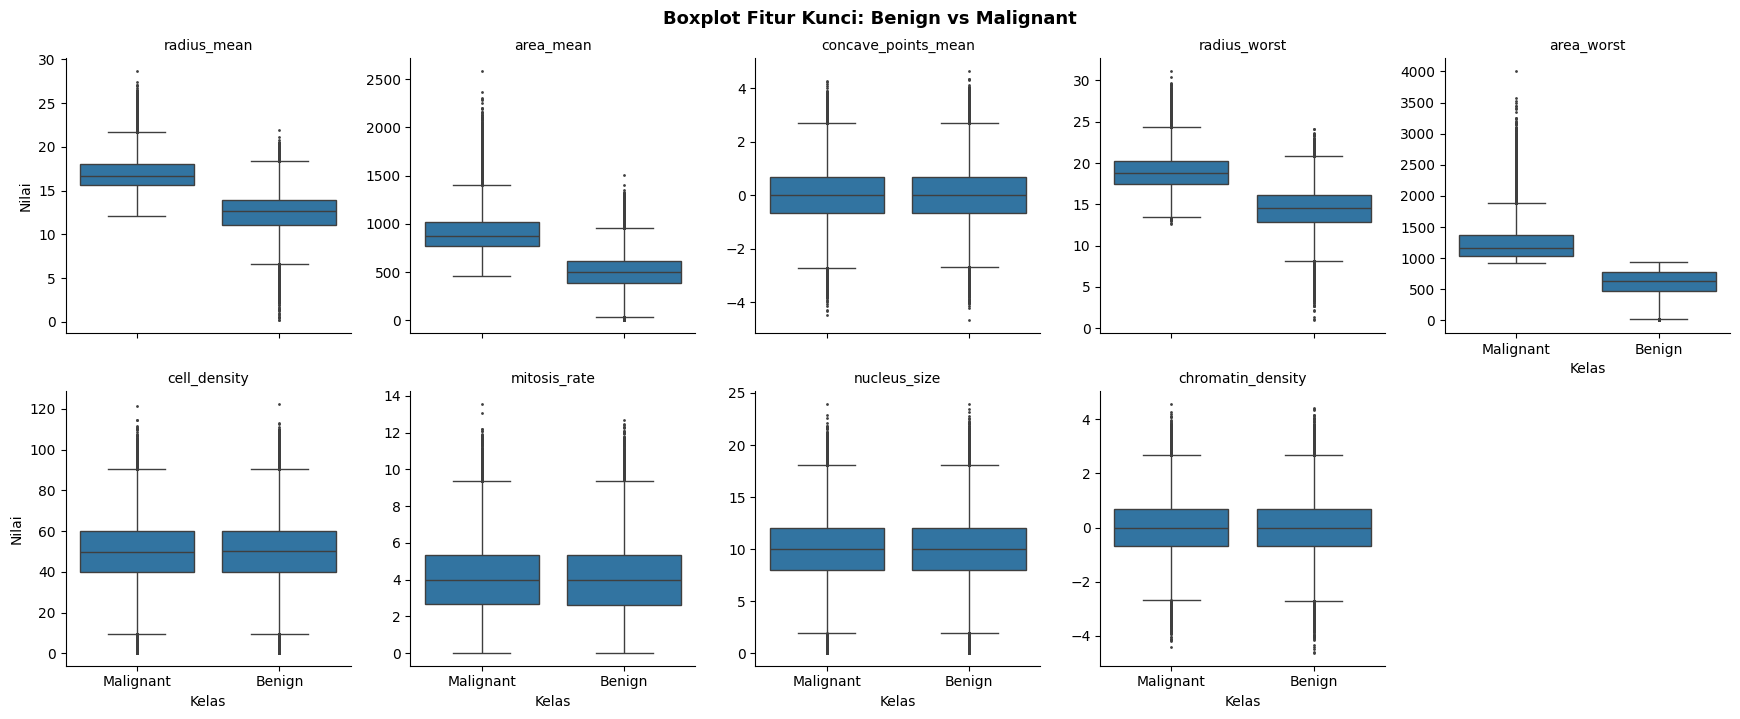

In [15]:
# Boxplot fitur-fitur kunci
key_features = ['radius_mean', 'area_mean', 'concave_points_mean',
                 'radius_worst', 'area_worst', 'cell_density',
                 'mitosis_rate', 'nucleus_size', 'chromatin_density']
key_features = [f for f in key_features if f in df.columns]

df_melt = df[key_features + [target_col]].melt(id_vars=target_col)
df_melt['label'] = df_melt[target_col].map({0: 'Benign', 1: 'Malignant'})

g = sns.FacetGrid(df_melt, col='variable', col_wrap=5, height=3.5, sharey=False)
g.map_dataframe(sns.boxplot, x='label', y='value', flierprops={'markersize': 1})
g.set_titles(col_template='{col_name}')
g.set_axis_labels('Kelas', 'Nilai')
g.figure.suptitle('Boxplot Fitur Kunci: Benign vs Malignant', fontsize=13, fontweight='bold', y=1.02)
plt.show()

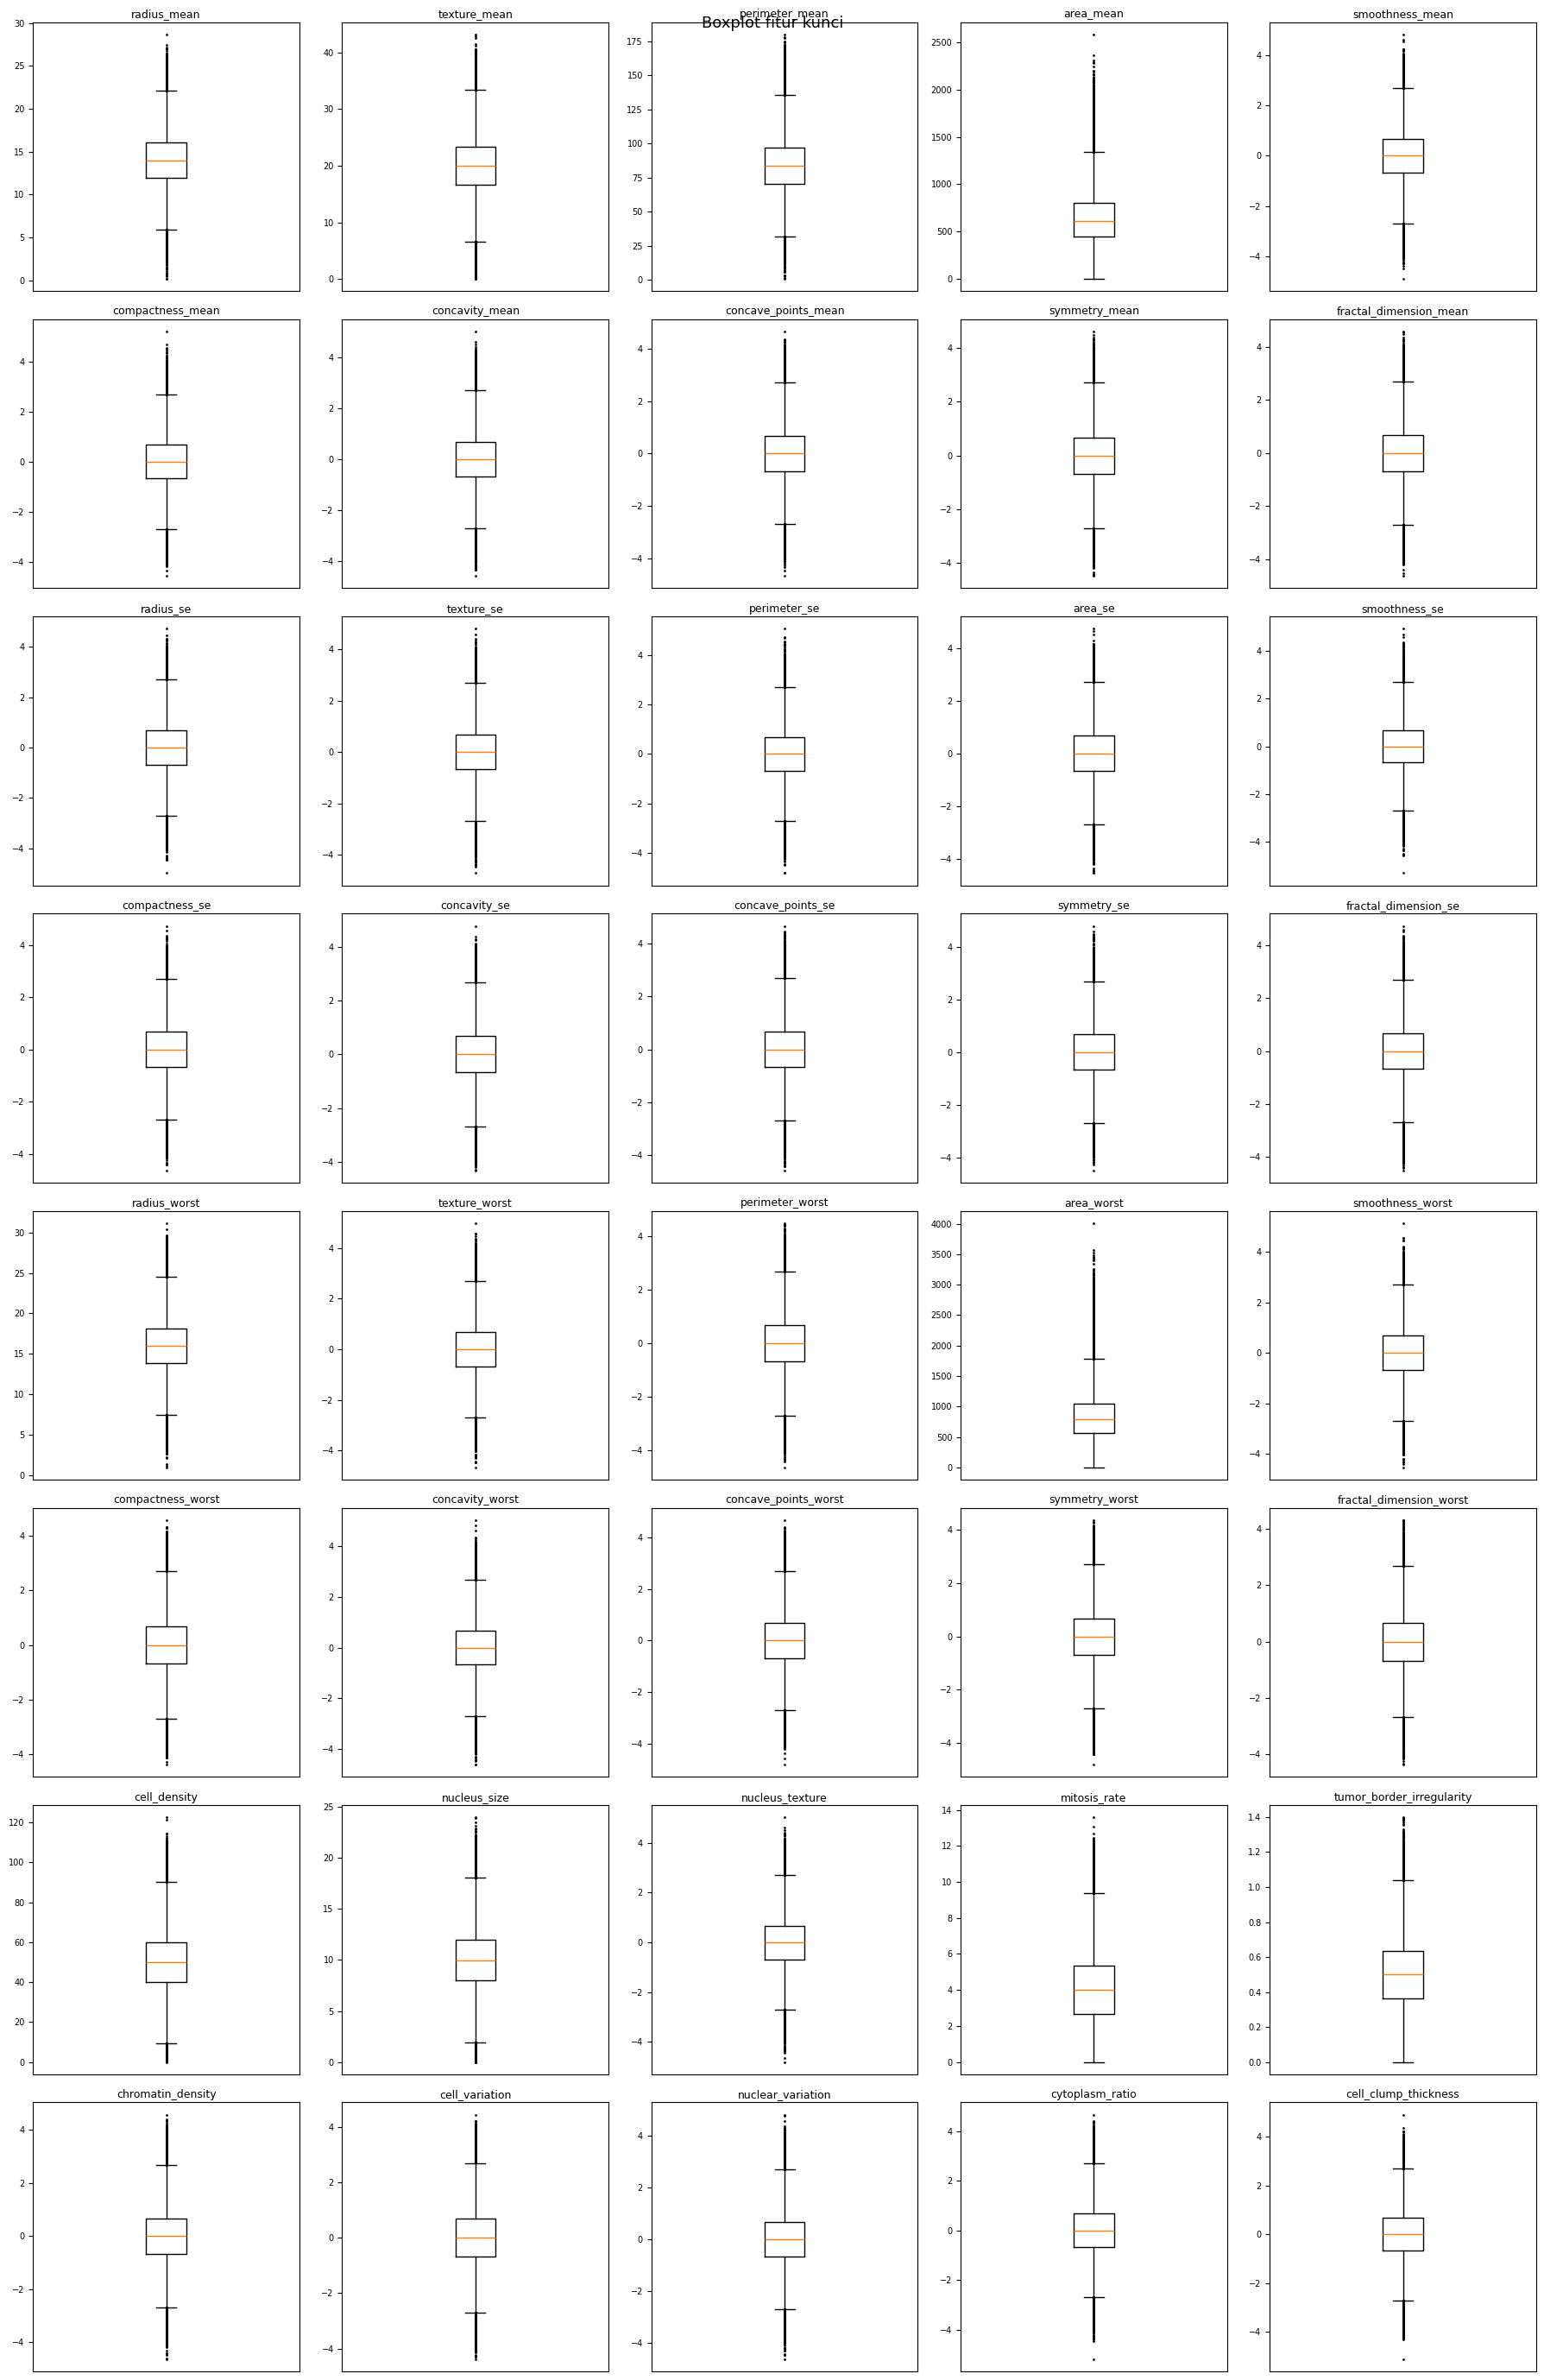

In [16]:
num_features = len(feature_cols)
n_cols = 5
n_rows = (num_features + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5)) # Adjust figsize height
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    ax.boxplot(df[col].dropna(), flierprops=dict(marker='.', markersize=2))
    ax.set_title(col, fontsize=9, pad=4)
    ax.set_xticks([])
    ax.tick_params(labelsize=7)

# This loop hides extra subplots if num_features is not a perfect multiple of n_cols
for j in range(num_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplot fitur kunci', fontsize=13)
plt.tight_layout()
plt.show()